# 06 · Training a PPO agent & evaluating it against the textbook baseline

The simulator ships a small but complete **reinforcement-learning stack** (`src/rl/`): a
PPO agent that wraps the supply chain as a Gymnasium environment and learns continuous
**pricing and ordering** for one trainable shop node. This notebook drives that stack
end-to-end:

1. **Train** a PPO agent with the `src.rl.train` CLI (a tiny, CPU-only run).
2. **Read the training curves** straight from the TensorBoard event file the run wrote.
3. **Evaluate** the trained checkpoint against the `OrderUpToPolicy` textbook baseline
   on Common-Random-Number-paired seeds, so any difference is the *policy*, not seed luck.

### What the env actually learns

Each episode the env (`src/rl/env.py`) builds a degenerate three-tier graph —
one `FactoryNode` per active SKU → one trainable `IntermediateNode("S")` → one
`DemandSinkNode` per SKU — and randomises the slice it trains on:

- a fresh **assortment** of `K_active` SKUs drawn from a larger catalog,
- a per-episode **store capacity** and **opening cash**, sampled *log-uniform across two
  orders of magnitude* so one policy generalises from corner-shop to flagship,
- **slot-shuffled** observations and **hidden** market state.

The agent's action is `2 · K_active` continuous values in `[-1, 1]`: price multipliers
(`× MSRP`) and order quantities (decoded order-up-to style). Reward each tick is node S's
cash delta; episode return is the sum, i.e. net profit.

> **Tiny-demo caveat.** Everything below runs in a couple of minutes on CPU with **no GPU
> and no API key**. The training budget here is a few thousand env steps — roughly
> **1/300th** of a real run. A policy that actually *beats* the baseline needs on the order
> of **~1,000,000 steps** (`--total-env-steps 1000000 --n-envs 8`). So expect the trained
> agent here to *lose* to the baseline: this notebook demonstrates the **mechanism**
> (train → curves → CRN-paired eval), not a competitive result.

In [1]:
%matplotlib inline
import os
from pathlib import Path

# Hop up to the repo root so `import src...` and relative paths resolve
# no matter where the kernel started.
while not (Path.cwd() / "pyproject.toml").exists():
    os.chdir("..")

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
plt.rcParams["figure.dpi"] = 90
print("cwd:", Path.cwd())

cwd: /Users/mislavjordanic/Documents/projects/personal_projects/supply_chain_simulator


## 1 · The training config (kept deliberately tiny)

`RLConfig` (`src/rl/configs/default.py`) is the single frozen dataclass every part of the
stack reads. Its real defaults — `K_active=5`, `episode_length=180`,
`total_env_steps=1_000_000`, `n_envs=8` — are tuned for a serious run. We override them
with much smaller values so the whole notebook finishes fast. The cell below just *names*
the knobs we'll pass to the CLI; we don't construct the config here (the CLI does).

In [2]:
DEMO = dict(
    total_env_steps=4000,   # real run: ~1_000_000
    n_envs=2,               # real run: 8
    episode_length=30,      # real run: 180
    k_active=3,             # real run: 5
    k_catalog=12,           # real run: 100
    n_steps=64,             # rollout length per env per update
    n_epochs=4,
    n_minibatches=2,
    eval_cadence=1000,      # CRN eval (+ checkpoint) every N env steps -> a few evals
    n_eval_seeds=6,         # real run: 32
)

EXPERIMENT = "nb06_demo"
RUN_ROOT = "data/notebook_demos/06/runs"   # gitignored; namespaced for this notebook
run_dir = Path(RUN_ROOT) / EXPERIMENT

# Start from a clean slate so re-running the notebook is idempotent.
import shutil
if run_dir.exists():
    shutil.rmtree(run_dir)

print("derived obs/action dims for K_active =", DEMO["k_active"], ":")
from src.rl.encoders import observation_dim, action_dim
print("  observation_dim =", observation_dim(DEMO["k_active"]), "(K_active*18 + 4)")
print("  action_dim      =", action_dim(DEMO["k_active"]), "(2*K_active: price mults + order qtys)")

derived obs/action dims for K_active = 3 :
  observation_dim = 58 (K_active*18 + 4)
  action_dim      = 6 (2*K_active: price mults + order qtys)


## 2 · Train a tiny agent

`src.rl.train` is an `argparse` driver: it builds a `SyncVectorEnv` of `RLEnv`s, wires a
TensorBoard `SummaryWriter`, builds the CRN eval callback, and calls `train_ppo(...)`. We
invoke it as a subprocess (the canonical entry point) with our tiny flags, pointing its
TensorBoard- and checkpoint-roots at our gitignored notebook directory.

With no `--setup-dir`, the stack falls back to a **synthetic catalog** of `--k-catalog`
products — no LLM, no `OPENAI_API_KEY` needed.

In [3]:
import subprocess, sys, time

cmd = [
    "uv", "run", "python", "-m", "src.rl.train",
    "--total-env-steps", str(DEMO["total_env_steps"]),
    "--n-envs", str(DEMO["n_envs"]),
    "--episode-length", str(DEMO["episode_length"]),
    "--k-active", str(DEMO["k_active"]),
    "--k-catalog", str(DEMO["k_catalog"]),
    "--n-steps", str(DEMO["n_steps"]),
    "--n-epochs", str(DEMO["n_epochs"]),
    "--n-minibatches", str(DEMO["n_minibatches"]),
    "--eval-cadence-env-steps", str(DEMO["eval_cadence"]),
    "--n-eval-seeds", str(DEMO["n_eval_seeds"]),
    "--experiment-name", EXPERIMENT,
    "--tb-log-dir", RUN_ROOT,
    "--checkpoint-dir", RUN_ROOT,
]
print("running:\n ", " ".join(cmd), "\n")

t0 = time.time()
proc = subprocess.run(cmd, capture_output=True, text=True)
wall = time.time() - t0

print(f"return code: {proc.returncode}   wall time: {wall:.1f}s\n")
# The driver logs to stderr; show the last lines (trim for brevity).
tail = [ln for ln in proc.stderr.splitlines() if ln.strip()][-12:]
print("\n".join(tail))
assert proc.returncode == 0, "training subprocess failed"  # gate: must succeed

running:
  uv run python -m src.rl.train --total-env-steps 4000 --n-envs 2 --episode-length 30 --k-active 3 --k-catalog 12 --n-steps 64 --n-epochs 4 --n-minibatches 2 --eval-cadence-env-steps 1000 --n-eval-seeds 6 --experiment-name nb06_demo --tb-log-dir data/notebook_demos/06/runs --checkpoint-dir data/notebook_demos/06/runs 



return code: 0   wall time: 4.7s

[train] device=cpu
[train] Synthetic catalog: 12 products.
[train] SyncVectorEnv: 2 envs, obs_dim=58, act_dim=6
[train] TensorBoard log dir: data/notebook_demos/06/runs/nb06_demo
[train] Eval enabled: 6 seeds, cadence=1000 env steps.
[train] Starting PPO: total_env_steps=4000, seed=0
[train] Final checkpoint saved: data/notebook_demos/06/runs/nb06_demo/checkpoints/actor_step0000004000.pt
[train] Done.


### What landed on disk

The run wrote a TensorBoard event file plus one checkpoint per eval call (and a final one
at `total_env_steps`). Checkpoints are bare `actor.state_dict()` tensors — the critic is
discarded after training since inference only needs the actor.

In [4]:
event_files = sorted(run_dir.glob("events.out.tfevents.*"))
ckpts = sorted((run_dir / "checkpoints").glob("actor_step*.pt"))

print("event files:", [p.name for p in event_files])
print("checkpoints:")
for p in ckpts:
    print(f"  {p.name}  ({p.stat().st_size/1024:.0f} KB)")
assert event_files and ckpts, "need at least one event file and one checkpoint"


event files: ['events.out.tfevents.1780939971.Mislavs-MacBook-Pro.local.51619.0']
checkpoints:
  actor_step0000000000.pt  (36 KB)
  actor_step0000000001.pt  (36 KB)
  actor_step0000000002.pt  (36 KB)
  actor_step0000004000.pt  (36 KB)


## 3 · Read the training curves

The event file holds the same scalars TensorBoard would show. We read it offline with
`EventAccumulator`, **print the available tags first** (never hard-code them), then plot
whichever exist. PPO logs `train/*` and `losses/*` every update; the CRN eval logs
`eval/*` at its cadence.

In [5]:
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

ea = EventAccumulator(str(event_files[0]))
ea.Reload()
scalar_tags = ea.Tags()["scalars"]
print(f"{len(scalar_tags)} scalar tags logged:\n")
for t in scalar_tags:
    print(" ", t)

def scalar_series(tag):
    "Return (steps, values) for a scalar tag, or ([], []) if absent."
    if tag not in scalar_tags:
        return [], []
    evs = ea.Scalars(tag)
    return [e.step for e in evs], [e.value for e in evs]

21 scalar tags logged:

  train/episodic_return
  train/episodic_length
  losses/value_loss
  losses/policy_loss
  losses/entropy
  losses/approx_kl
  losses/clipfrac
  charts/learning_rate
  charts/SPS
  eval/rl_return
  eval/baseline_return
  eval/paired_uplift
  eval/win_rate
  eval/rl_stockout_rate
  eval/rl_inventory_turnover
  eval/rl_mean_price_pct_of_msrp
  eval/rl_net_profit
  eval/baseline_stockout_rate
  eval/baseline_inventory_turnover
  eval/baseline_mean_price_pct_of_msrp
  eval/baseline_net_profit


### Training-loop scalars

A handful of the most telling `train/*` and `losses/*` curves. With only a few thousand
steps these are short and noisy — that's the point. On a real run `losses/entropy` drifts
down as the policy sharpens and `train/episodic_return` trends up.

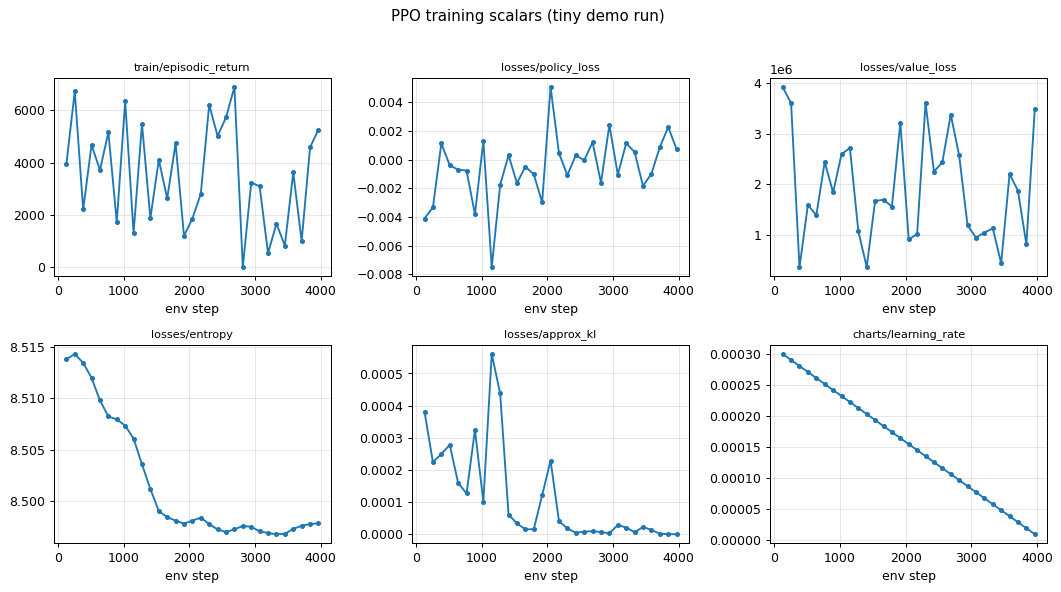

In [6]:
panel_tags = [
    "train/episodic_return",
    "losses/policy_loss",
    "losses/value_loss",
    "losses/entropy",
    "losses/approx_kl",
    "charts/learning_rate",
]
present = [t for t in panel_tags if t in scalar_tags]

ncol = 3
nrow = (len(present) + ncol - 1) // ncol
fig, axes = plt.subplots(nrow, ncol, figsize=(12, 3.2 * nrow))
axes = axes.ravel()
for ax, tag in zip(axes, present):
    steps, vals = scalar_series(tag)
    ax.plot(steps, vals, marker="o", ms=3)
    ax.set_title(tag, fontsize=9)
    ax.set_xlabel("env step")
    ax.grid(alpha=0.3)
for ax in axes[len(present):]:
    ax.axis("off")
fig.suptitle("PPO training scalars (tiny demo run)", y=1.02)
plt.tight_layout()
plt.show()

### The CRN eval scalars logged *during* training

The eval callback also writes `eval/*` scalars at every cadence point. `eval/paired_uplift`
is the headline number: the mean per-seed `(RL − baseline)` net profit on identical worlds.
Below we overlay RL vs baseline return, and track uplift + win-rate over training.

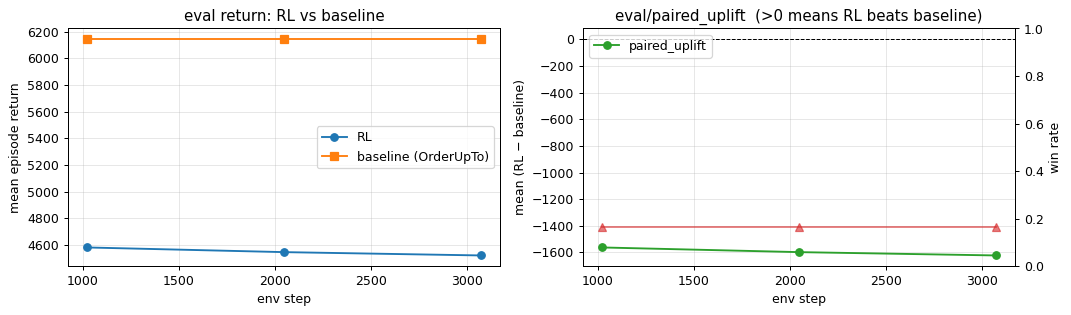

final logged paired_uplift: -1622.6   (negative is expected at this tiny budget)


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))

s_rl, v_rl = scalar_series("eval/rl_return")
s_bl, v_bl = scalar_series("eval/baseline_return")
if v_rl:
    axes[0].plot(s_rl, v_rl, marker="o", label="RL")
if v_bl:
    axes[0].plot(s_bl, v_bl, marker="s", label="baseline (OrderUpTo)")
axes[0].set_title("eval return: RL vs baseline")
axes[0].set_xlabel("env step"); axes[0].set_ylabel("mean episode return")
axes[0].legend(); axes[0].grid(alpha=0.3)

s_up, v_up = scalar_series("eval/paired_uplift")
s_wr, v_wr = scalar_series("eval/win_rate")
ax2 = axes[1]
if v_up:
    ax2.plot(s_up, v_up, marker="o", color="C2", label="paired_uplift")
    ax2.axhline(0, color="k", lw=0.8, ls="--")
ax2.set_title("eval/paired_uplift  (>0 means RL beats baseline)")
ax2.set_xlabel("env step"); ax2.set_ylabel("mean (RL − baseline)")
ax2.grid(alpha=0.3)
if v_wr:
    ax2b = ax2.twinx()
    ax2b.plot(s_wr, v_wr, marker="^", color="C3", alpha=0.6, label="win_rate")
    ax2b.set_ylabel("win rate"); ax2b.set_ylim(0, 1)
ax2.legend(loc="upper left")
plt.tight_layout()
plt.show()

if v_up:
    print(f"final logged paired_uplift: {v_up[-1]:+.1f}   "
          f"(negative is expected at this tiny budget)")

## 4 · Evaluate the trained checkpoint vs the baseline (CRN-paired)

The training-time `eval/*` scalars are aggregated, so here we reproduce the eval *offline*
to get the full metrics dict and per-seed detail. The recipe (identical to what
`train.py`'s eval callback does):

1. Load the latest checkpoint into a fresh `Actor` (same `K_active` it trained with).
2. Wrap it in a `(obs_np) → action_np` closure using `actor.get_action_and_log_prob`.
3. Build a held-out CRN eval set with `build_eval_seeds(...)`.
4. Call `evaluate(rl_policy_fn, baseline_policy_factory, eval_specs, config=...)` from
   `src/rl/eval.py`, with the baseline factory returning a fresh `OrderUpToPolicy()`.

The CRN guarantee: for each seed, the RL and baseline arms share
`(world_seed, capacity, balance, active subset, slot permutation)`, so world stochasticity
cancels exactly — any gap is the policy.

In [8]:
import torch, numpy as np
from src.rl.agents.ppo import Actor
from src.rl.configs.default import RLConfig
from src.rl.episode_sampler import make_synthetic_catalog
from src.rl.eval import build_eval_seeds, evaluate
from src.sim.policy import OrderUpToPolicy

# Rebuild the config that matches the run we just trained.
cfg = RLConfig(
    K_active=DEMO["k_active"],
    K_catalog=DEMO["k_catalog"],
    episode_length=DEMO["episode_length"],
    n_eval_seeds=DEMO["n_eval_seeds"],
)

obs_dim = observation_dim(cfg.K_active)
act_dim = action_dim(cfg.K_active)
actor = Actor(obs_dim, act_dim)

latest_ckpt = ckpts[-1]
actor.load_state_dict(torch.load(latest_ckpt))
actor.eval()
print("loaded checkpoint:", latest_ckpt.name)

def rl_policy_fn(obs_np):
    obs_t = torch.tensor(obs_np, dtype=torch.float32).unsqueeze(0)
    with torch.no_grad():
        action, _, _ = actor.get_action_and_log_prob(obs_t)
    return action.squeeze(0).numpy()

loaded checkpoint: actor_step0000004000.pt


### Run the paired evaluation

In [9]:
# A synthetic catalog of the same size the run trained on, then a fixed held-out
# seed set (seeds live far above the training range, so they're never seen in training).
catalog = make_synthetic_catalog(cfg.K_catalog)
eval_specs = build_eval_seeds(catalog, cfg, n_seeds=DEMO["n_eval_seeds"])
print(f"built {len(eval_specs)} held-out CRN eval specs")

metrics = evaluate(
    rl_policy_fn=rl_policy_fn,
    baseline_policy_factory=lambda: OrderUpToPolicy(),
    eval_specs=eval_specs,
    config=cfg,
)

# Tidy the flat eval/* dict into an RL-vs-baseline KPI table.
rows = []
for kpi in ["return", "net_profit", "stockout_rate",
            "inventory_turnover", "mean_price_pct_of_msrp"]:
    rl_k, bl_k = f"eval/rl_{kpi}", f"eval/baseline_{kpi}"
    if rl_k in metrics and bl_k in metrics:
        rows.append((kpi, metrics[rl_k], metrics[bl_k]))
kpi_df = pd.DataFrame(rows, columns=["kpi", "RL", "baseline"])
kpi_df["RL − baseline"] = kpi_df["RL"] - kpi_df["baseline"]
display(kpi_df.set_index("kpi").round(3))

print(f"\npaired_uplift (mean RL − baseline net profit per seed): "
      f"{metrics['eval/paired_uplift']:+.1f}")
print(f"win_rate (fraction of seeds where RL >= baseline):       "
      f"{metrics['eval/win_rate']:.2f}")

built 6 held-out CRN eval specs


,RL,baseline,RL − baseline
kpi,,,
return,4615.015,6142.838,-1527.823
net_profit,4615.015,6142.838,-1527.823
stockout_rate,0.230,0.011,0.219
inventory_turnover,3.318,5.709,-2.392
mean_price_pct_of_msrp,1.000,1.000,0.000



paired_uplift (mean RL − baseline net profit per seed): -1527.8
win_rate (fraction of seeds where RL >= baseline):       0.17


### Visualise the head-to-head

A bar chart of RL vs baseline return, and the per-seed picture. We recover per-seed numbers
by calling the same `evaluate(...)` with a **one-spec list** per seed — exactly the trick
the comparison notebook uses to expose detail the aggregate hides.

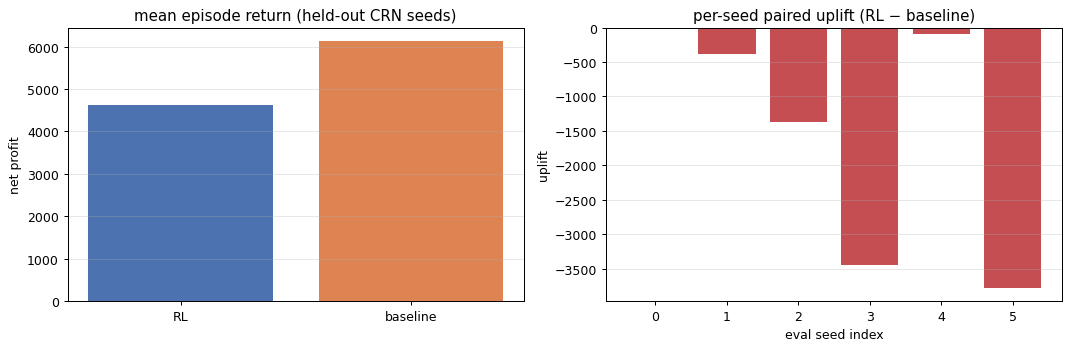

,seed_idx,rl_return,baseline_return,uplift
0,0,6228.4,6228.4,0.0
1,1,7267.0,7657.2,-390.2
2,2,1633.3,2997.4,-1364.0
3,3,1554.4,4996.6,-3442.2
4,4,8566.4,8666.4,-100.0
5,5,2530.8,6311.1,-3780.3


In [10]:
# Per-seed RL & baseline returns: evaluate each spec on its own.
per_seed = []
for i, spec in enumerate(eval_specs):
    m1 = evaluate(rl_policy_fn, lambda: OrderUpToPolicy(), [spec], config=cfg)
    per_seed.append((i, m1["eval/rl_return"], m1["eval/baseline_return"]))
seed_df = pd.DataFrame(per_seed, columns=["seed_idx", "rl_return", "baseline_return"])
seed_df["uplift"] = seed_df["rl_return"] - seed_df["baseline_return"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: aggregate mean return bars.
axes[0].bar(["RL", "baseline"],
            [metrics["eval/rl_return"], metrics["eval/baseline_return"]],
            color=["#4C72B0", "#DD8452"])
axes[0].set_title("mean episode return (held-out CRN seeds)")
axes[0].set_ylabel("net profit")
axes[0].grid(axis="y", alpha=0.3)

# Right: per-seed paired uplift bars (color by sign).
colors = ["#55A868" if u >= 0 else "#C44E52" for u in seed_df["uplift"]]
axes[1].bar(seed_df["seed_idx"], seed_df["uplift"], color=colors)
axes[1].axhline(0, color="k", lw=0.8)
axes[1].set_title("per-seed paired uplift (RL − baseline)")
axes[1].set_xlabel("eval seed index"); axes[1].set_ylabel("uplift")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()
display(seed_df.round(1))

### Reading the result honestly

At ~4,000 env steps the agent has barely begun to learn, so the baseline `OrderUpToPolicy`
— a hand-tuned, near-optimal textbook rule — almost certainly wins (negative `paired_uplift`,
win-rate below 0.5). **That is the expected, correct outcome for a tiny demo.** What this
notebook proves is that every link in the chain works:

- the PPO loop trains and logs scalars + checkpoints,
- the curves are recoverable offline from the event file,
- the trained actor loads and runs the simulator,
- the CRN-paired evaluator produces an apples-to-apples comparison where the *only*
  difference between the two arms is the policy.

To actually beat the baseline, scale the budget up: `--total-env-steps 1000000 --n-envs 8`
with the default `K_active=5`, `episode-length=180`, optionally `--setup-dir setups/...` to
train on a real catalog. The headline you're chasing is a **positive and stable**
`eval/paired_uplift`.

## Where to next

- `src/rl/README.md` — the full RL stack reference: observation/action layout, CLI flags,
  checkpoint format, and the CRN eval contract.
- `uv run tensorboard --logdir data/notebook_demos/06/runs/` — view these curves live in
  the browser (overlay multiple runs to compare sweeps).
- Earlier notebooks: **04** compares the four textbook policies under CRN, **05** tunes one
  with Optuna — the same baseline this PPO agent is measured against.
- **Notebook 06a** loads a *long-trained* run from disk and analyzes it in depth —
  training trajectory, best-checkpoint selection, deep CRN comparison, and regime analysis.